# Figure 3c

# Picking the best longitude

### Here we treat longitude as the only free parameter to separate our flower observations into two groups: east vs. west. 
### If there were only one response, we could just try to find the longitude that maximizes a t-test. 
### Since there are 3 response variables (i.e. 3 color components), we will find the longitude that maximizes Hotelling's $T^2$, a multivariate stat.

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind

# for converting cielab to LCh
from colormath.color_objects import LabColor, LCHabColor
from colormath.color_conversions import convert_color

# multivariate t-test package
from pingouin import multivariate_ttest

### Read in data

In [2]:
color_df = pd.read_csv('../datasets/1-clusters/geo_med.csv')

### Pick random image if duplicates for an observation

In [3]:
color_df_reduced = (
    color_df.groupby("gbifID", sort=False, group_keys=False)
    .apply(lambda x: x.sample(1,random_state=123))
    .reset_index(drop=True)
)
color_df_reduced

/var/folders/qh/c7rwx84921n2kznn09zb2pnh0000gn/T/ipykernel_77754/1712891894.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1,random_state=123))


,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude
0,0,#d4b4e2,"(212, 180, 226)","(0.782608695652174, 0.44230769230769224, 0.796...","(197, 148, 109)",923911394,https://inaturalist-open-data.s3.amazonaws.com...,48.826305,-102.092171
1,2,#cdb3cd,"(205, 179, 205)","(0.8333333333333334, 0.2063492063492065, 0.752...","(193, 142, 118)",923910407,https://inaturalist-open-data.s3.amazonaws.com...,43.613086,-73.057076
2,4,#bda5d7,"(189, 165, 215)","(0.7466666666666667, 0.3846153846153846, 0.745...","(182, 146, 106)",899970365,https://inaturalist-open-data.s3.amazonaws.com...,43.066871,-87.890565
3,7,#9984ae,"(153, 132, 174)","(0.75, 0.2058823529411765, 0.6000000000000001)","(149, 144, 109)",891778924,https://inaturalist-open-data.s3.amazonaws.com...,42.140556,-87.831643
4,9,#ba9fdd,"(186, 159, 221)","(0.739247311827957, 0.476923076923077, 0.74509...","(178, 150, 100)",891760719,https://inaturalist-open-data.s3.amazonaws.com...,38.679240,-97.990035
...,...,...,...,...,...,...,...,...,...
16582,41059,#a191c2,"(161, 145, 194)","(0.7210884353741497, 0.2865497076023391, 0.664...","(161, 144, 105)",1024218211,https://inaturalist-open-data.s3.amazonaws.com...,41.569419,-88.150552
16583,41060,#b77fb7,"(183, 127, 183)","(0.8333333333333334, 0.28, 0.607843137254902)","(154, 159, 107)",1024202810,https://inaturalist-open-data.s3.amazonaws.com...,45.057871,-87.168277
16584,41061,#af96cb,"(175, 150, 203)","(0.7452830188679246, 0.3375796178343948, 0.692...","(168, 148, 104)",1024200169,https://inaturalist-open-data.s3.amazonaws.com...,42.921738,-88.026752
16585,41063,#c5b9b2,"(197, 185, 178)","(0.06140350877192979, 0.1407407407407409, 0.73...","(194, 131, 133)",1024198670,https://inaturalist-open-data.s3.amazonaws.com...,40.791723,-80.492498


### split Lab into separate components and get it into the "literal" metric rather than the opencv default of 0-255

In [4]:
L = [(int(i.strip('()').split(', ')[0])) for i in color_df_reduced.lab]
L = (np.array(L) / 255.0) * 100.0  
color_df_reduced['L'] = L
a = [(int(i.strip('()').split(', ')[1])) for i in color_df_reduced.lab]
a = np.array(a) - 128.0  
color_df_reduced['a'] = a
b = [(int(i.strip('()').split(', ')[2])) for i in color_df_reduced.lab]
b = np.array(b) - 128.0
color_df_reduced['b'] = b

# Use pinguoin's implementation of multivariate t-testing with Hotelling's $T^2$

## On CIELAB values

In [5]:
color_df_reduced.longitude.min()

np.float64(-135.308341)

In [6]:
color_df_reduced.longitude.max()

np.float64(-61.4335)

In [7]:
t2s = []
lons = []
for focal_lon in np.linspace(color_df_reduced.longitude.min(), color_df_reduced.longitude.max(),1000):
    west  = color_df_reduced.longitude < focal_lon
    east  = ~west
    west_df = color_df_reduced[west][['L','a','b']]
    east_df = color_df_reduced[east][['L','a','b']]
    if (len(west_df) > 100) and (len(east_df) > 100):
        res = multivariate_ttest(west_df,east_df)
        t2s.append(res.T2.iloc[0])
        lons.append(focal_lon)

In [8]:
best_lon = lons[np.argmax(t2s)]
best_lon

np.float64(-97.668406996997)

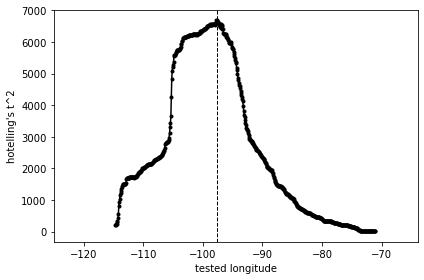

In [9]:
plt.plot(lons, t2s, marker='o', ms=3,c='black')
plt.axvline(best_lon, ls='--', lw=1, color='k')
plt.xlabel('tested longitude')
plt.ylabel('hotelling\'s t^2')
plt.xlim(-130+5,-59-5)
plt.tight_layout()
plt.savefig('../figures/figures_current/components/figure_3c.pdf',dpi=300)
plt.show()

# Best longitude stats

In [10]:
west  = color_df_reduced.longitude < best_lon
east  = ~west
west_df = color_df_reduced[west][['L','a','b']]
east_df = color_df_reduced[east][['L','a','b']]

In [11]:
mtt = multivariate_ttest(west_df,east_df)

In [12]:
mtt

,T2,F,df1,df2,pval
hotelling,6685.69004,2228.294602,3,16583,0.0


In [13]:
n_west = len(west_df)
n_east = len(east_df)

In [14]:
F, df1, df2, T2 = mtt.loc['hotelling'][['F', 'df1', 'df2', 'T2']]

In [15]:
#####
# https://real-statistics.com/multivariate-statistics/hotellings-t-square-statistic/one-sample-hotellings-t-square/hotellings-t-square-effect-size/
#####

partial_eta2 = (F*df1) / (F*df1+df2)
partial_eta2

0.28730089347498267

In [16]:
D=np.sqrt(T2*(n_west+n_east)/(n_west*n_east))
D

np.float64(1.7429886007438349)